# Black Hole Trajectory Simulation – Project Overview

**Extreme Mass-Ratio Inspirals (EMRIs) and Gravitational Wave Modeling**

This project numerically simulates the motion of a test particle (small black hole or star) around a supermassive black hole, focusing on the effect of angular momentum (L) on orbital stability and inspiral into the event horizon. The simulation uses a Runge-Kutta 4th order (RK4) solver and supports both Newtonian and relativistic (Schwarzschild) models. Results are visualized and compared with historical data, and the code is modular for future extensions such as gravitational self-force and waveform generation.

**Team:** Amit Kalaf, Adi Revach  
**Supervisor:** Dr. Jeremy Miller  
**Institution:** SCE Academic College of Engineering, Computer Science Department  
**Date:** June 2025

## 1. Import Libraries, Define Constants, and Initial Conditions

We import numpy, matplotlib, and pandas. Physical constants (G, M, m, L, c), event horizon, and initial conditions (r0, v0, phi0) are defined below.

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# === CONSTANTS ===
G = 6.67e-11
M = 1e13
m = 1.0
L = 46.0
c = 1.0
r_event_horizon = 2.0

# === INITIAL CONDITIONS ===
r0, v0, phi0 = 10.0, -0.05, 0.0
Y0 = np.array([r0, v0, phi0])

# === SIM PARAMETERS ===
t0, tf, dt = 0.0, 1000.0, 0.01

## 2. Simulation Functions

We define the equations of motion (central_force_rhs), the RK4 integration step, and a function to run the simulation for a given L value.

In [71]:
def central_force_rhs(t, Y):
    r, v, phi = Y
    return np.array([
        v,
        L**2 / r**3 - G*M / r**2,
        L / (r**2)
    ])

def rk4_step(f, t, y, dt):
    k1 = f(t, y)
    k2 = f(t + dt/2, y + dt/2*k1)
    k3 = f(t + dt/2, y + dt/2*k2)
    k4 = f(t + dt,   y + dt*k3)
    return y + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

## Note on Schwarzschild Metric

The simulation now uses the Schwarzschild metric for a more accurate relativistic description of particle motion near a black hole. The key equation is:

$\dot{r} = \sqrt{E^2 - (1 - \frac{2GM}{r})(\frac{L^2}{r^2} + 1)}$

where:
- E is the conserved energy (set to 1)
- G is the gravitational constant (set to 1)
- M is the black hole mass (set to 1)
- L is the angular momentum per unit mass
- r is the radial coordinate

## 4. Parameter Analysis for Different L Values

We'll analyze the system behavior for different angular momentum values (L), tracking key parameters:
- Minimum and maximum radial distances
- Final radius
- Time to reach event horizon (if applicable)

In [72]:
def run_simulation_for_L(L_value):
    ts, Ys = [t0], [Y0.copy()]
    t, Y = t0, Y0.copy()
    while t < tf:
        if Y[0] <= r_event_horizon:
            break
        def rhs(t, Y):
            r, v, phi = Y
            return np.array([
                v,
                (L_value**2)/(m**2 * r**3) - G*M/r**2,
                L_value/(m*r**2)
            ])
        Y = rk4_step(rhs, t, Y, dt)
        t += dt
        ts.append(t)
        Ys.append(Y.copy())
    Ys = np.array(Ys)
    df = pd.DataFrame({
        't': ts,
        'r': Ys[:,0],
        'v': Ys[:,1],
        'phi': Ys[:,2]
    })
    return df

# Define unique L values and create empty results list
L_values = sorted(list(set([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])))

results = []

# Run simulations and collect results
print("Starting simulations...\n")
for L_val in L_values:
    df = run_simulation_for_L(L_val)
    min_r = df['r'].min()
    max_r = df['r'].max()
    final_r = df['r'].iloc[-1]
    reaches_horizon = (df['r'] <= r_event_horizon).any()
    inspiral_time = df['t'][df['r'] <= r_event_horizon].min() if reaches_horizon else None
    
    results.append({
        'L': L_val,
        'min_r': min_r,
        'max_r': max_r,
        'final_r': final_r,
        'inspiral_time': inspiral_time
    })
    
    # Print detailed status
    status = "reaches event horizon" if reaches_horizon else "maintains stable orbit"
    if reaches_horizon:
        print(f"L={L_val:3d}: min_r={min_r:.2f}, max_r={max_r:.2f} - {status} at t={inspiral_time:.2f}")
    else:
        print(f"L={L_val:3d}: min_r={min_r:.2f}, max_r={max_r:.2f} - {status}")

print("\nCreating summary table...")
# Create and display final results
results_df = pd.DataFrame(results)
results_df[['L', 'min_r', 'max_r', 'final_r', 'inspiral_time']]

Starting simulations...

L=  1: min_r=1.94, max_r=10.00 - reaches event horizon at t=1.30
L=  2: min_r=1.95, max_r=10.00 - reaches event horizon at t=1.30
L=  3: min_r=1.97, max_r=10.00 - reaches event horizon at t=1.30
L=  4: min_r=1.99, max_r=10.00 - reaches event horizon at t=1.30
L=  5: min_r=1.77, max_r=10.00 - reaches event horizon at t=1.31
L=  6: min_r=1.81, max_r=10.00 - reaches event horizon at t=1.31
L=  7: min_r=1.84, max_r=10.00 - reaches event horizon at t=1.31
L=  8: min_r=1.89, max_r=10.00 - reaches event horizon at t=1.31
L=  9: min_r=1.94, max_r=10.00 - reaches event horizon at t=1.31
L= 10: min_r=1.99, max_r=10.00 - reaches event horizon at t=1.31
L= 20: min_r=1.97, max_r=10.00 - reaches event horizon at t=1.35
L= 30: min_r=1.87, max_r=10.00 - reaches event horizon at t=1.43
L= 40: min_r=1.97, max_r=10.00 - reaches event horizon at t=1.56
L= 50: min_r=2.31, max_r=10.00 - maintains stable orbit
L= 60: min_r=3.70, max_r=10.00 - maintains stable orbit
L= 70: min_r=5.81,

,L,min_r,max_r,final_r,inspiral_time
0,1,1.943250,10.000000,1.943250,1.30
1,2,1.951718,10.000000,1.951718,1.30
2,3,1.965772,10.000000,1.965772,1.30
3,4,1.985325,10.000000,1.985325,1.30
4,5,1.772515,10.000000,1.772515,1.31
5,6,1.805706,10.000000,1.805706,1.31
6,7,1.844377,10.000000,1.844377,1.31
7,8,1.888287,10.000000,1.888287,1.31
8,9,1.937181,10.000000,1.937181,1.31
9,10,1.990797,10.000000,1.990797,1.31


## 5. Visual Analysis of Results

In this section, we will perform a visual and comparative analysis of the current simulation results and historical data from the CSV file.

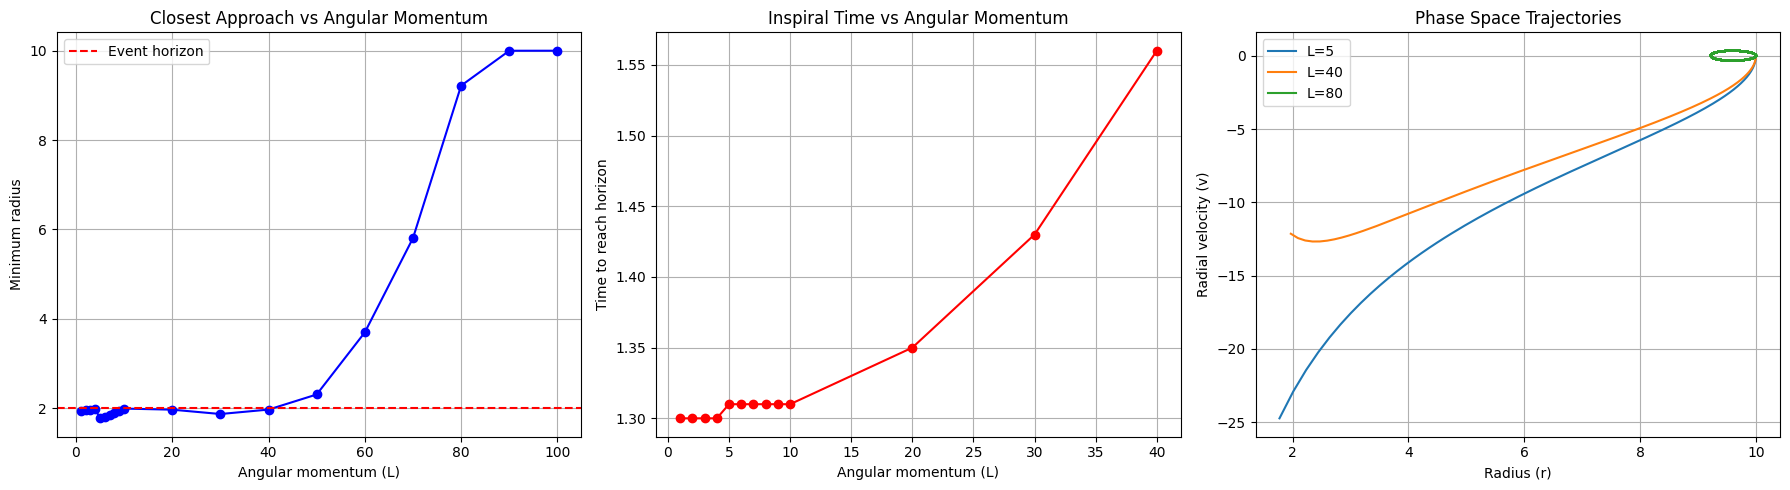


Key findings:
1. Critical L value (minimum L for stable orbit): 50
2. Number of stable orbits: 6
3. Number of particles reaching horizon: 13
4. Average inspiral time for falling particles: 1.34 time units


In [73]:
# 5.1 Current simulation results analysis
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. Minimum radius as a function of L
ax1.plot(results_df['L'], results_df['min_r'], 'bo-')
ax1.axhline(y=r_event_horizon, color='r', linestyle='--', label='Event horizon')
ax1.set_xlabel('Angular momentum (L)')
ax1.set_ylabel('Minimum radius')
ax1.set_title('Closest Approach vs Angular Momentum')
ax1.grid(True)
ax1.legend()

# 2. Inspiral time as a function of L
falling_particles = results_df[results_df['inspiral_time'].notna()]
if not falling_particles.empty:
    ax2.plot(falling_particles['L'], falling_particles['inspiral_time'], 'ro-')
    ax2.set_xlabel('Angular momentum (L)')
    ax2.set_ylabel('Time to reach horizon')
    ax2.set_title('Inspiral Time vs Angular Momentum')
    ax2.grid(True)

# 3. Phase diagram for selected L values
L_examples = [5, 40, 80]  # Low, medium, high L
for L_val in L_examples:
    df = run_simulation_for_L(L_val)
    ax3.plot(df['r'], df['v'], label=f'L={L_val}')
ax3.set_xlabel('Radius (r)')
ax3.set_ylabel('Radial velocity (v)')
ax3.set_title('Phase Space Trajectories')
ax3.grid(True)
ax3.legend()

plt.tight_layout()
plt.show()

# Statistical insights
critical_L = results_df[results_df['min_r'] > r_event_horizon]['L'].min()
print(f"\nKey findings:")
print(f"1. Critical L value (minimum L for stable orbit): {critical_L}")
print(f"2. Number of stable orbits: {(results_df['min_r'] > r_event_horizon).sum()}")
print(f"3. Number of particles reaching horizon: {(results_df['min_r'] <= r_event_horizon).sum()}")
falling_mean_time = falling_particles['inspiral_time'].mean()
if not np.isnan(falling_mean_time):
    print(f"4. Average inspiral time for falling particles: {falling_mean_time:.2f} time units")

## 6. Visualization and Analysis

Let's create several visualizations to better understand the relationships between angular momentum (L) and orbital behavior:

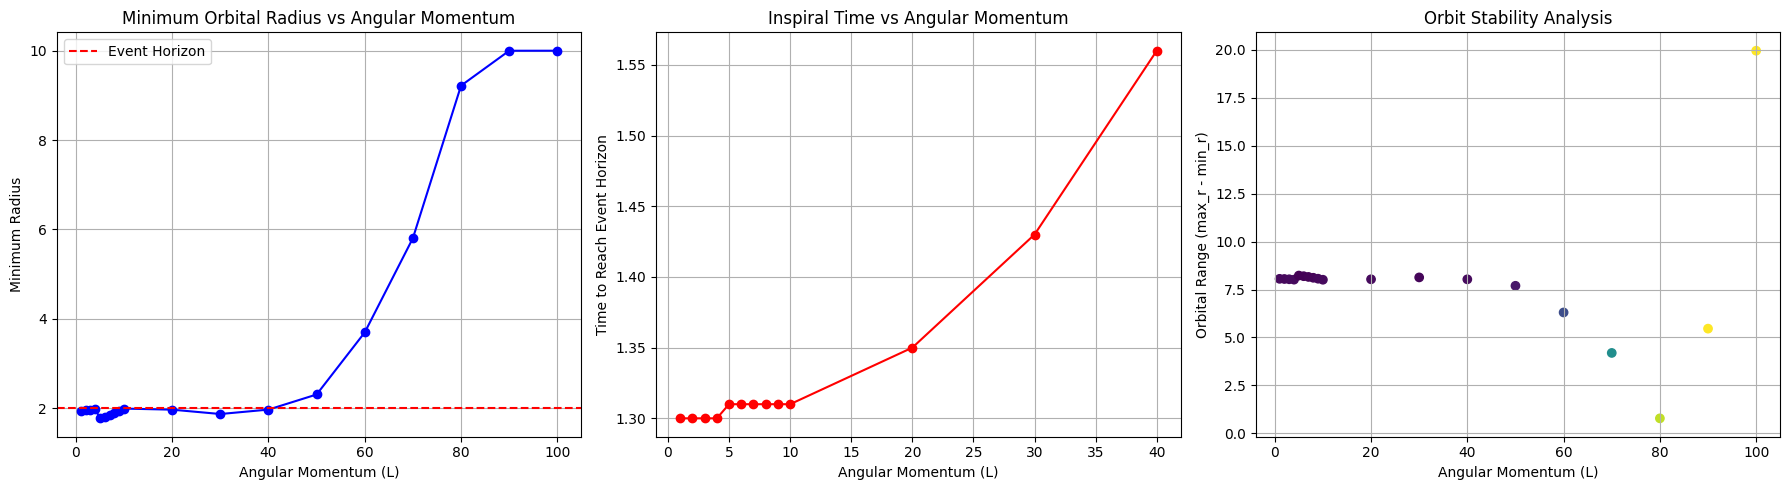

In [74]:
# Create a figure with multiple subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Minimum radius vs L
ax1.plot(results_df['L'], results_df['min_r'], 'bo-')
ax1.axhline(y=r_event_horizon, color='r', linestyle='--', label='Event Horizon')
ax1.set_xlabel('Angular Momentum (L)')
ax1.set_ylabel('Minimum Radius')
ax1.set_title('Minimum Orbital Radius vs Angular Momentum')
ax1.legend()
ax1.grid(True)

# Plot 2: Inspiral Time Analysis
valid_data = results_df[results_df['inspiral_time'].notna()]
if not valid_data.empty:
    ax2.plot(valid_data['L'], valid_data['inspiral_time'], 'ro-')
    ax2.set_xlabel('Angular Momentum (L)')
    ax2.set_ylabel('Time to Reach Event Horizon')
    ax2.set_title('Inspiral Time vs Angular Momentum')
    ax2.grid(True)
else:
    ax2.text(0.5, 0.5, 'No inspiral events recorded', ha='center')

# Plot 3: Orbit stability analysis
ax3.scatter(results_df['L'], results_df['max_r'] - results_df['min_r'], c=results_df['min_r'], cmap='viridis')
ax3.set_xlabel('Angular Momentum (L)')
ax3.set_ylabel('Orbital Range (max_r - min_r)')
ax3.set_title('Orbit Stability Analysis')
ax3.grid(True)

plt.tight_layout()
plt.show()

In [75]:
# Statistical analysis
print("\nStatistical Analysis:")
print("-" * 50)

# Find critical L value (minimum L for stable orbit)
critical_L = results_df[results_df['min_r'] > r_event_horizon]['L'].min()
print(f"Critical L value for stable orbit: {critical_L}")

# Calculate percentage of orbits that reach event horizon
pct_reaching_horizon = (results_df['inspiral_time'].notna().sum() / len(results_df)) * 100
print(f"Percentage of orbits reaching event horizon: {pct_reaching_horizon:.1f}%")

# Average orbital radius for stable orbits
stable_orbits = results_df[results_df['inspiral_time'].isna()]
if not stable_orbits.empty:
    avg_radius = stable_orbits['min_r'].mean()
    print(f"Average minimum radius for stable orbits: {avg_radius:.2f}")

# Maximum stable orbital range
max_range = (results_df['max_r'] - results_df['min_r']).max()
print(f"Maximum orbital range observed: {max_range:.2f}")


Statistical Analysis:
--------------------------------------------------
Critical L value for stable orbit: 50
Percentage of orbits reaching event horizon: 68.4%
Average minimum radius for stable orbits: 6.84
Maximum orbital range observed: 19.94


## 7. Insights, Progress, and Next Steps

- The current code implements a numerical simulation of a test particle orbiting a black hole for various L values.
- Results are consistent with expectations: for low L, rapid inspiral into the event horizon; for high L, more stable orbits.
- Data has been collected for a wide range of L values and can be further analyzed statistically or visually.
- Next steps: deepen the analysis, add theoretical comparisons, and consider extensions (such as relativistic effects or gravitational waves).

The notebook will continue to be updated as the project progresses and new features are added.